In [2]:
import os

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

import seaborn as sns
from ast import literal_eval

from typing import Dict, List, Optional, Tuple
from datetime import datetime, timedelta
import time

import glob
import json
import requests
from pprint import pprint

from concurrent.futures import ProcessPoolExecutor, as_completed
import logging

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import PartialDependenceDisplay

# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import plotly.express as px
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time
import requests
import re

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
!pip install linearmodels

In [5]:
np.random.seed(42)

In [8]:
def grid_search_cv(param_grid, model, X_train_scaled, y_train, X_test_scaled, y_test):

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("Best parameters found:", best_params)
    print("Best cross-validation score (negative MSE):", grid_search.best_score_)

    model_pred = best_model.predict(X_test_scaled)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    print(f"Test RMSE: {model_rmse:.4f}")
    print(f"Test R²: {model_r2:.4f}")
    
    return best_params, best_model

In [10]:
def prepare_data(df, features, target_col='next_day_3_log_return'):

    data = df.copy()
    
    data = data.dropna(subset=[target_col])
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    X = data[features]
    y = data[target_col]
    
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['int64', 'float64']:
#                 X[col].fillna(X[col].median(), inplace=True)
#                 X[col].fillna(X[col].mean(), inplace=True)
                X[col].fillna(0., inplace=True)
    
    return X, y

def data_train_test_split(df, features, target_col, q=2, test_size=0.1):
    X, y = prepare_data(df, features, target_col=target_col)

    y_bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, 
#         stratify=y_bins
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    print(round(y_train.mean(), 3), round(y_test.mean(), 3))
    
    return X_train_scaled, X_test_scaled, y_train, y_test

In [12]:
def scatter_regplot(x, y, **kws):
    ax = plt.gca()
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    # Линия регрессии
    sns.regplot(x=x, y=y, scatter=False, 
                line_kws={'color': 'red', 'alpha': 0.8, 'linewidth': 2})
    r, p_value = stats.pearsonr(x, y)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

def diag_kde(x, **kws):
    ax = plt.gca()
    sns.histplot(x, kde=True, stat="density", alpha=0.7, ax=ax)

    mean_val = x.mean()
    median_val = x.median()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.3f}')
    if ax.get_subplotspec().is_first_row() and ax.get_subplotspec().is_first_col():
        ax.legend(loc='upper right', fontsize=8)

def lower_hexbin(x, y, **kws):
    ax = plt.gca()
    hb = ax.hexbin(x, y, gridsize=30, cmap='Blues', alpha=0.8, mincnt=1)
    plt.colorbar(hb, ax=ax, shrink=0.7)

In [14]:
def calculate_pvalues(df, method='pearson'):
    n = df.shape[1]
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                p_matrix[i, j] = 0
            else:
                if method == 'pearson':
                    corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
                elif method == 'spearman':
                    corr, p_value = spearmanr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
    return pd.DataFrame(p_matrix, index=df.columns, columns=df.columns)

def annotate_with_pvalues(corr_matrix, p_matrix):
    annot_matrix = np.empty_like(corr_matrix, dtype=object)
    n = corr_matrix.shape[0]
    
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_matrix[i, j] = '1.00'
            elif mask[i, j]: 
                annot_matrix[i, j] = ''
            else:
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                stars = ''
                if p_val < 0.01:
                    stars = '***'
                elif p_val < 0.05:
                    stars = '**'
                elif p_val < 0.1:
                    stars = '*'
                
                annot_matrix[i, j] = f'{corr_val:.2f}{stars}'
    
    return annot_matrix

def plot_corr_matrix(corr_matrix, mask, annotations, title='Correlation with p-values'):
    plt.figure(figsize=(12, 10))
    heatmap = sns.heatmap(corr_matrix,
                mask=mask,
                annot=annotations,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='', 
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9})

    plt.title(title, fontsize=16, pad=20)

    legend_text = '\n'.join([
        '*** p < 0.01',
        '** p < 0.05', 
        '* p < 0.1',
    #     'Без звездочек: p ≥ 0.05'
    ])
    plt.figtext(0.72, 0.92, legend_text, fontsize=10, 
               bbox=dict(boxstyle="round, pad=0.5", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

def get_coordinates_photon(zip_code, state=None):
    try:
        if state:
            query = f"{zip_code}, {state}, USA"
        else:
            query = f"{zip_code}, USA"
        
        url = f"https://photon.komoot.io/api/?q={query}&limit=1"
        response = requests.get(url, timeout=10)
        data = response.json()
        
        if data['features']:
            coords = data['features'][0]['geometry']['coordinates']
            return coords[1], coords[0]  # lat, lon
        return None, None
    except Exception as e:
        print(f"Error geocoding {zip_code}: {e}")
        return None, None

def get_coordinates_with_retry(zip_code, state, max_retries=3):
    for attempt in range(max_retries):
        try:
            lat, lon = get_coordinates_photon(zip_code, state)
            if lat and lon:
                return lat, lon
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {zip_code}: {e}")
            time.sleep(2)
    return None, None

def parse_industry_file_with_expanded_codes(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    
    industry_blocks = re.split(r'\n\s*\n', content.strip())
    
    data = []
    
    for block in industry_blocks:
        lines = block.strip().split('\n')
        
        if len(lines) < 2:
            continue
        
        first_line = lines[0].strip()
        match = re.match(r'(\d+)\s+(\w+)\s+(.+)', first_line)
        
        if match:
            industry_num = int(match.group(1))
            industry_code = match.group(2)
            industry_name = match.group(3).strip()
            
            # Обрабатываем диапазоны кодов
            for line in lines[1:]:
                line = line.strip()
                if line and re.match(r'\d{4}-\d{4}', line):
                    start, end = map(int, line.split('-'))
                    
                    # Создаем отдельную запись для каждого кода в диапазоне
                    for code in range(start, end + 1):
                        data.append({
                            'industry_number': industry_num,
                            'industry_code': industry_code,
                            'industry_name': industry_name,
                            'sic_code': code
                        })
    
    return pd.DataFrame(data)

    
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix,
#             mask=mask,
#             annot=True,
#             cmap='RdBu_r',
#             center=0,
#             square=True,
#             fmt='.2f',
#             linewidths=0.5,
#             cbar_kws={'shrink': 0.8})

# plt.title('Correlation', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

In [16]:
def category_plot(col, depvar, data,
                  order=None, ylabel=None, xlabel=None,
                  path=None, ax=None, verbose=False):
    sns.set(style="ticks")
    nobs = data[col].value_counts()
    medians = data.groupby(col,observed=True)[depvar].median()
    means = data.groupby(col,observed=True)[depvar].mean()
    if verbose:
        print(f"{means=}")
        print(f"p-value={f_oneway(*[data.loc[data[col]==c,depvar] for c in nobs.index.to_list()]).pvalue}")
    if not order:
        order = list(nobs.index.sort_values())
        box = sns.boxenplot(data=data, x=col, y=depvar, order=order, width=0.8,
                      linewidth=0.8, linecolor="0.2", ax=ax);
        box.set(xlabel=xlabel if xlabel else None, ylabel=ylabel if ylabel else "Llama Polarity");
    for i, c in enumerate(order):
        box.text(i, medians[c]-0.01, "n="+str(nobs[c]),
                  horizontalalignment='center',
                  fontdict={'fontsize':9});
        box.text(i, means[c], "x",
                  horizontalalignment='center',
                  fontdict={'fontsize':8, 'color':'red'});
    if path:
        path = join(tables_path, path)
        plt.savefig(path, bbox_inches='tight');
    return box

## Target

- 10-K CAR[0,1] The cumulative market-adjusted return for the firm in the [0,1] trading window surrounding the current-
year 10-K filing date

## Control variables


- BTM Book to market ratio calculated as the firm’s book value of common equity at the end of quarter or year
divided by MVE

- INSTOWN ML 10-K CAR[0,1] The percentage of shares of the firm held by institutional investors

- MVE Market value of equity for the firm in the current quarter or year calculated as the firm’s stock price
multiplied by the number of shares outstanding at the end of the quarter or year

- NASDAQ An indicator variable equal to the one if the firm is traded on the NASDAQ and equal to zero otherwise

- PRE_FFALPHA It is the Fama–French alpha based on a regression of their three-factor model using trading days [−252,−6]
relative to the conference call or 10-K filing date. At least 60 observations of daily returns must be
available to be included in the sample.

- TURNOVER The number of shares traded for the firm in the trading days [−252,−6] relative to the conference call or
10-K filing date divided by the firm’s shares outstanding at the conference call or 10-K filing date

## Data

### Reports

In [20]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [22]:
report_path = '.'
reports = pd.read_csv(os.path.join(report_path, '10k_filtered.tsv.gz'), sep='\t')
reports['tick'] = reports['ticker'].apply(literal_eval).apply(lambda x: x[0])
reports = reports.reset_index()
reports['FFInd'] = reports['FFInd'].astype(str)
reports['SIC'] = reports['SIC'].astype(int).astype(str)
# reports = reports.merge(ffind48[['major_code', 'major_name']].drop_duplicates(), left_on='FFInd', right_on='major_code', how='left')
reports = reports.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

reports['industry_number'] = reports['industry_number'].fillna(12)
reports['industry_code'] = reports['industry_code'].fillna('Other')
reports['industry_name'] = reports['industry_name'].fillna('Other -- Mines, Constr, BldMt, Trans, Hotels, Bus Serv, Entertainment')
reports = reports.drop('sic_code', axis=1)
reports['CIK'] = reports['CIK'].astype(str)

In [23]:
reports.tail()

,index,CIK,FILING_DATE,ACC_NUM,CPR,FORM_TYPE,CoName,SIC,FFInd,N_Words,N_Unique_Words,N_Negative,N_Positive,N_Uncertainty,N_Litigious,N_StrongModal,N_WeakModal,N_Constraining,N_Complexity,N_Negation,filing_date,filer_cik,filer_count,filing_agent_cik,filing_agent_tot,g_abs_asset_class_1,g_abs_asset_class_2,g_acceptance_datetime,g_accession_number,g_confirming_copy,g_conformed_period_of_report,g_conformed_submission_type,g_date_as_of_change,g_filed_as_of_date,g_public_document_count,cd_company_conformed_name,cd_central_index_key,cd_standard_industrial_classification,cd_organization_name,cd_irs_number,cd_state_of_incorporation,cd_fiscal_year_end,fv_form_type,fv_sec_act,fv_sec_file_number,fv_film_number,ba_street_1,ba_street_2,ba_city,ba_state,ba_zip,ba_business_phone,ma_street_1,ma_street_2,ma_city,ma_state,ma_zip,fc_former_conformed_name_1,fc_date_of_name_change_1,fc_former_conformed_name_2,fc_date_of_name_change_2,fc_former_conformed_name_3,fc_date_of_name_change_3,fc_former_conformed_name_4,fc_date_of_name_change_4,fc_former_conformed_name_5,fc_date_of_name_change_5,FILING_YEAR,filing_dt,prev_filing_dt,days_between_filings,cik,ticker,title,tick,industry_number,industry_code,industry_name
50255,50255,1948455,20230919,0001213900-23-077437,20230630,10-K,Ispire Technology Inc.,2111,5,47413,3491,1007,333,762,581,194,469,413,212,47,20230919.0,1948455.0,1of1,1213900.0,77437.0,NaN,NaN,2.023092e+13,0001213900-23-077437,NaN,20230630.0,10-K,20230919.0,20230919.0,97.0,Ispire Technology Inc.,1948455.0,2111.0,NaN,845106049.0,DE,630.0,10-K,1934 Act,001-41680,231262452.0,19700 MAGELLAN DRIVE,NaN,LOS ANGELES,CA,90502,3107429975,19700 MAGELLAN DRIVE,NaN,LOS ANGELES,CA,90502,Ispire Technology Inc,20220927.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2023-09-19,NaN,NaN,1948455,['ispr'],['Ispire Technology Inc.'],ispr,1.0,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile..."
50256,50256,1951276,20230928,0000950170-23-050475,20230630,10-K,SR Bancorp Inc.,6036,44,50467,3225,946,266,709,565,178,396,441,108,38,20230928.0,1951276.0,1of1,950170.0,50475.0,NaN,NaN,2.023093e+13,0000950170-23-050475,NaN,20230630.0,10-K,20230928.0,20230928.0,91.0,SR Bancorp Inc.,1951276.0,6036.0,NaN,0.0,MD,630.0,10-K,1934 Act,001-41808,231290211.0,220 WEST UNION AVENUE,NaN,BOUND BROOK,NJ,08805,(732) 560-1700,220 WEST UNION AVENUE,NaN,BOUND BROOK,NJ,08805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2023-09-28,NaN,NaN,1951276,['srbk'],"['SR Bancorp, Inc.']",srbk,11.0,Money,Finance
50257,50257,1967306,20231229,0001558370-23-020031,20230930,10-K,Mercer Bancorp Inc.,6036,44,37580,2852,673,153,439,500,78,202,344,63,40,20231229.0,1967306.0,1of1,1558370.0,20031.0,NaN,NaN,2.023123e+13,0001558370-23-020031,NaN,20230930.0,10-K,20231229.0,20231229.0,92.0,Mercer Bancorp Inc.,1967306.0,6036.0,02 Finance,0.0,MD,930.0,10-K,1934 Act,000-56575,231528550.0,1100 IRMSCHER BLVD,NaN,CELINA,OH,45822,(419) 586-5158,1100 IRMSCHER BLVD,NaN,CELINA,OH,45822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2023-12-29,NaN,NaN,1967306,['msbb'],"['Mercer Bancorp, Inc.']",msbb,11.0,Money,Finance
50258,50258,1967649,20231221,0001967649-23-000025,20230929,10-K,Vestis Corp,5190,41,67974,3790,1059,426,894,765,334,429,576,262,29,20231221.0,1967649.0,1of1,1967649.0,25.0,NaN,NaN,2.023122e+13,0001967649-23-000025,NaN,20230929.0,10-K,20231221.0,20231221.0,56.0,Vestis Corp,1967649.0,5190.0,07 Trade & Services,922573927.0,DE,930.0,10-K,1934 Act,001-41783,231505996.0,500 COLONIAL CENTER PARKWAY,SUITE 140,ROSWELL,GA,30076,470-226-3655,500 COLONIAL CENTER PARKWAY,SUITE 140,ROSWELL,GA,30076,Epic NewCo Inc.,20230228.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2023-12-21,NaN,NaN,1967649,['vsts'],['Vestis Corp'],vsts,9.0,Shops,"Wholesale, Retail, and Some Services (Laundrie..."
50259,50259,1978811,20231226,0001558370-23-020009,20230930,10-K,Gouverneur Bancorp Inc./MD/,6036,44,40790,2916,915,215,615,379,89,249,398,144,35,20231226.0,1978811.0,1of1,1558370.0,20009.0,NaN,NaN,2.023123e+13,0001558370-23-020009,NaN,20230930.0,10-K,20231226.0,2

### Replication data from Frankel 

In [27]:
df = pd.read_sas('replication_package_MS-ACC-20-00126/data/finaldata_10k.sas7bdat')
df.tail()

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01
75357,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1079.670621,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893
75358,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1066.343151,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591
75359,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,737.888756,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175
75360,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,334320819.0,142348.0,2348.616201,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623
75361,b'318728',2018-12-31,39.83,197.100,8276.000,0.722051,55804.0,16496.0,2019-02-27,b'1527469_0001527469-19-000007',7850.49300,1.054201,338861633.0,164849.0,2055.588041,-0.000151,0.0,0.006164,0.007526,0.013676,-0.290089,0.078818,0.049895,0.224715,0.001628,-0.119722,-0.002462,2019.0,8.968332,-1.054262


In [29]:
df['date_filed'] = df['date_filed'].astype(str)
df['ACC_NUM'] = df['filename'].astype(str).str.split('_').str[1]
df['CIK'] = df['filename'].astype(str).str.split('_').str[0]
df['FILING_DATE'] = df['date_filed'].astype(str).str.replace('-', '')

cols_to_winsorize = ['tone', 'tone_pos', 'tone_neg', 'tone_harvard', 'tone_posharvard', 'tone_negharvard', 'mve', 'factorpred_car01']

for column in cols_to_winsorize:
    df[column] = winsorize(df[column], limits=[0.01, 0.01])

df['turnover'] = df['turnover'] / 1000

In [31]:
reports_96 = df.copy()
reports_96 = df[df['FILING_DATE'].astype(str).str[:4] < '2013'].reset_index(drop=True)
reports_96 = reports_96[['CIK', 'FILING_DATE', 'ACC_NUM']]
reports_96 = reports_96.reset_index()
reports_96.shape

(53495, 4)

In [33]:
# reports_m = reports.merge(df, left_on=['ACC_NUM', 'CIK', 'filing_dt'], right_on=['ACC_NUM', 'CIK', 'date_filed'])
# reports_m.shape[0]

## Sentiments from Llama 3.1
### 2013 -- 2023

In [36]:
# with open('item7_lengths.pickle', 'rb') as f:
#     lengths = pickle.load(f)
    
# item7_len = pd.DataFrame.from_dict(lengths, orient='index')
# item7_len.columns = ['item7_length']
# item7_len = item7_len.reset_index()

general_sent = pd.read_csv('sentiments/final_results_general.csv')
revenue_sent = pd.read_csv('sentiments/final_results_revenue.csv')
profit_sent = pd.read_csv('sentiments/final_results_profit.csv')

strategic_risk_sent = pd.read_csv('sentiments/final_results_strategic_risk.csv')
operational_risk_sent = pd.read_csv('sentiments/final_results_operational_risk.csv')
financial_risk_sent = pd.read_csv('sentiments/final_results_financial_risk.csv')
reputational_risk_sent = pd.read_csv('sentiments/final_results_reputational_risk.csv')
compliance_risk_sent = pd.read_csv('sentiments/final_results_compliance_risk.csv')

In [38]:
general_sent = general_sent.rename(columns={col: col+'_general' for col in general_sent.columns if col != 'index'})
revenue_sent = revenue_sent.rename(columns={col: col+'_revenue' for col in revenue_sent.columns if col != 'index'})
profit_sent = profit_sent.rename(columns={col: col+'_profit' for col in profit_sent.columns if col != 'index'})

strategic_risk_sent = strategic_risk_sent.rename(columns={col: col+'_strategic_risk' for col in strategic_risk_sent.columns if col != 'index'})
operational_risk_sent = operational_risk_sent.rename(columns={col: col+'_operational_risk' for col in operational_risk_sent.columns if col != 'index'})
financial_risk_sent = financial_risk_sent.rename(columns={col: col+'_financial_risk' for col in financial_risk_sent.columns if col != 'index'})

reputational_risk_sent = reputational_risk_sent.rename(columns={col: col+'_reputation_risk' for col in reputational_risk_sent.columns if col != 'index'})
compliance_risk_sent = compliance_risk_sent.rename(columns={col: col+'_compliance_risk' for col in compliance_risk_sent.columns if col != 'index'})

# sent = general_sent.merge(item7_len, on='index')\

sent = general_sent.merge(revenue_sent, on='index')\
.merge(profit_sent, on='index')\
.merge(strategic_risk_sent, on='index')\
.merge(operational_risk_sent, on='index')\
.merge(financial_risk_sent, on='index')\
.merge(reputational_risk_sent, on='index')\
.merge(compliance_risk_sent, on='index')

In [40]:
sent.shape

(48719, 25)

In [42]:
sent_13_23 = reports[['index', 'CIK', 'FILING_DATE', 'ACC_NUM']].merge(sent, on='index')
sent_13_23.shape

(48719, 28)

### 1996 -- 2012

In [45]:
general_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_general.csv')
revenue_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_revenue.csv')
profit_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_profit.csv')

strategic_risk_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_strategic_risk.csv')
operational_risk_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_operational_risk.csv')
financial_risk_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_financial_risk.csv')
reputational_risk_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_reputational_risk.csv')
compliance_risk_sent_96 = pd.read_csv('sentiments_1996_2012/final_results_compliance_risk.csv')

general_sent_96 = general_sent_96.rename(columns={col: col+'_general' for col in general_sent_96.columns if col != 'index'})
revenue_sent_96 = revenue_sent_96.rename(columns={col: col+'_revenue' for col in revenue_sent_96.columns if col != 'index'})
profit_sent_96 = profit_sent_96.rename(columns={col: col+'_profit' for col in profit_sent_96.columns if col != 'index'})

strategic_risk_sent_96 = strategic_risk_sent_96.rename(columns={col: col+'_strategic_risk' for col in strategic_risk_sent_96.columns if col != 'index'})
operational_risk_sent_96 = operational_risk_sent_96.rename(columns={col: col+'_operational_risk' for col in operational_risk_sent_96.columns if col != 'index'})
financial_risk_sent_96 = financial_risk_sent_96.rename(columns={col: col+'_financial_risk' for col in financial_risk_sent_96.columns if col != 'index'})
reputational_risk_sent_96 = reputational_risk_sent_96.rename(columns={col: col+'_reputation_risk' for col in reputational_risk_sent_96.columns if col != 'index'})
compliance_risk_sent_96 = compliance_risk_sent_96.rename(columns={col: col+'_compliance_risk' for col in compliance_risk_sent_96.columns if col != 'index'})

sent_96 = general_sent_96.merge(revenue_sent_96, on='index')\
.merge(profit_sent_96, on='index')\
.merge(strategic_risk_sent_96, on='index')\
.merge(operational_risk_sent_96, on='index')\
.merge(financial_risk_sent_96, on='index')\
.merge(reputational_risk_sent_96, on='index')\
.merge(compliance_risk_sent_96, on='index')

In [47]:
sent_96_12 = reports_96.merge(sent_96, on='index')
sent_96_12.shape

(40661, 28)

In [49]:
np.all(np.array(sent_96_12.columns) == np.array(sent_13_23.columns))

True

In [51]:
sent_96_12 = sent_96_12.drop('index', axis=1)
sent_13_23 = sent_13_23.drop('index', axis=1)

In [53]:
sent_96_12[['CIK', 'FILING_DATE', 'ACC_NUM']].drop_duplicates().shape, sent_13_23[['CIK', 'FILING_DATE', 'ACC_NUM']].drop_duplicates().shape

((40661, 3), (48719, 3))

In [55]:
all_sent = pd.concat([sent_96_12, sent_13_23], axis=0, ignore_index=True)
all_sent.shape, all_sent.drop_duplicates(['CIK', 'FILING_DATE', 'ACC_NUM']).shape

((89380, 27), (89380, 27))

In [57]:
all_sent['FILING_DATE'].str[:4].value_counts().sort_index()

FILING_DATE
1996     975
1997    1499
1998    1719
1999    1897
2000    1903
2001    1795
2002    2044
2003    2702
2004    2290
2005    2659
2006    2893
2007    3128
2008    3181
2009    3108
2010    3077
2011    2914
2012    2877
Name: count, dtype: int64

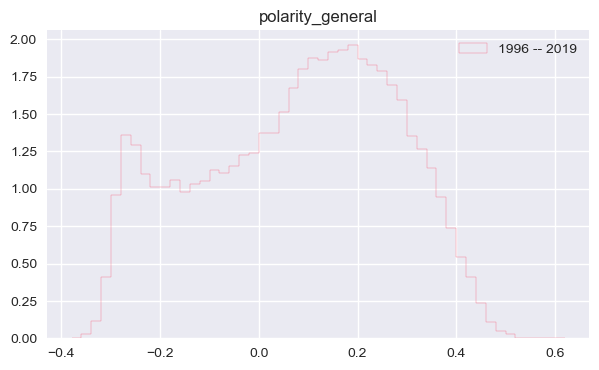

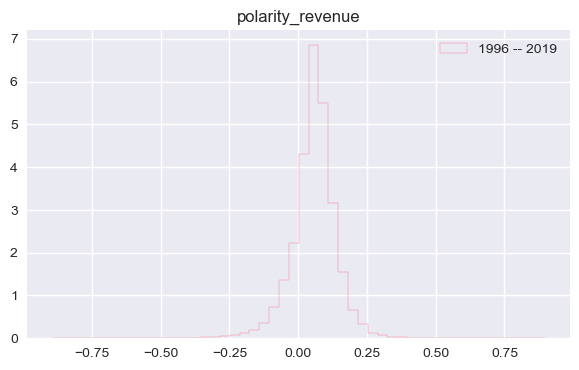

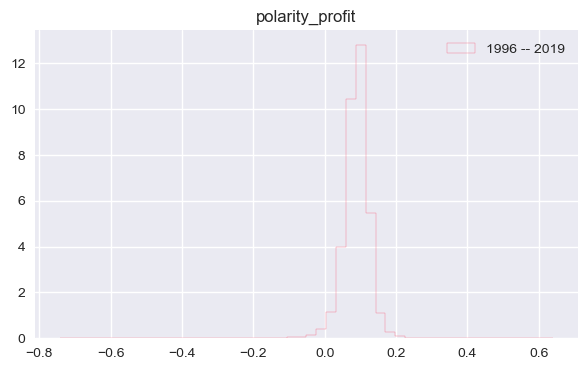

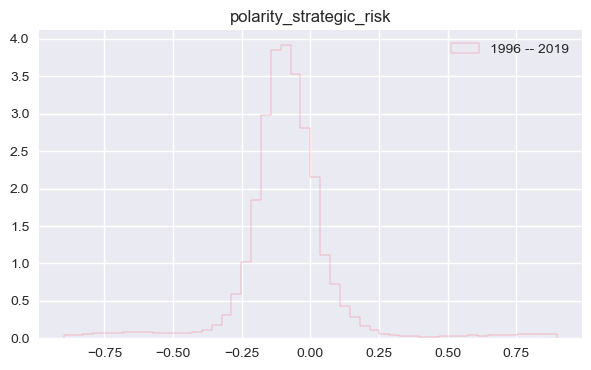

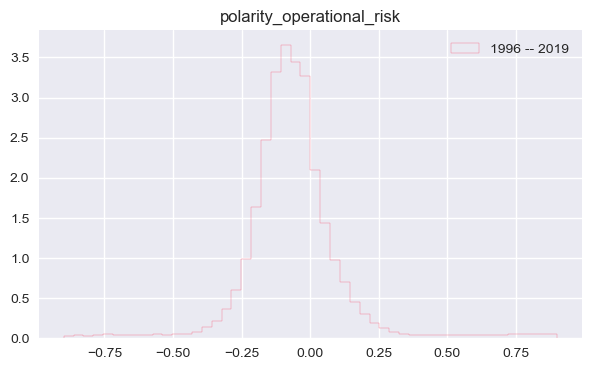

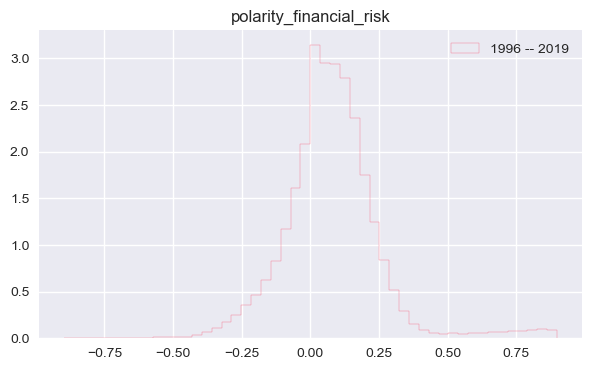

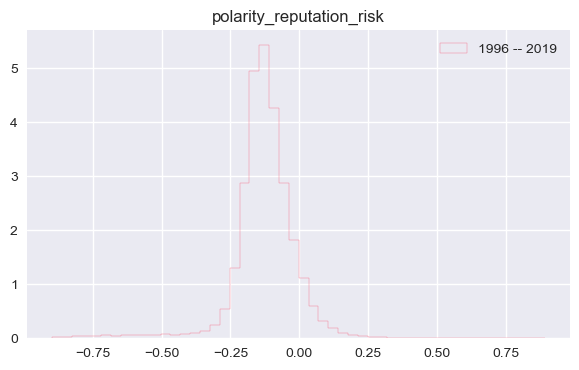

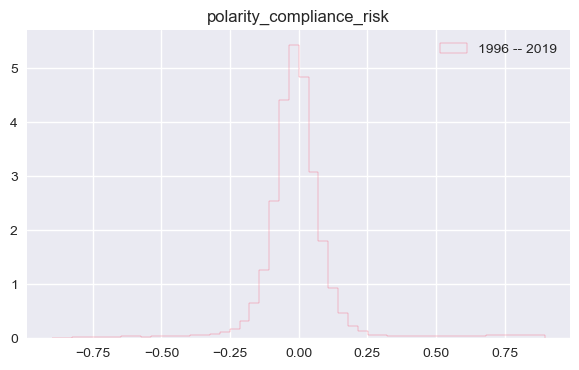

In [787]:
llama = [col for col in sent.columns if 'polarity' in col]

for col in llama: 
    plt.figure(figsize=(7, 4))
    plt.title(col)
    # plt.hist(sent_96[col], bins=50, label='1996 -- 2012', density=True, histtype='step')
    # plt.hist(sent[col], bins=50, label='2013 -- 2023', density=True, histtype='step')
    plt.hist(all_sent[col], bins=50, label='1996 -- 2019', density=True, histtype='step')
    plt.legend()
    plt.show()

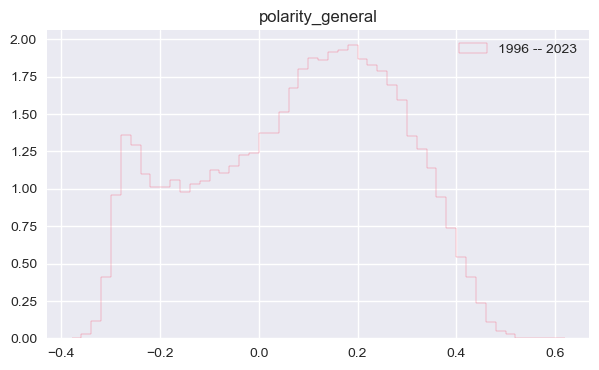

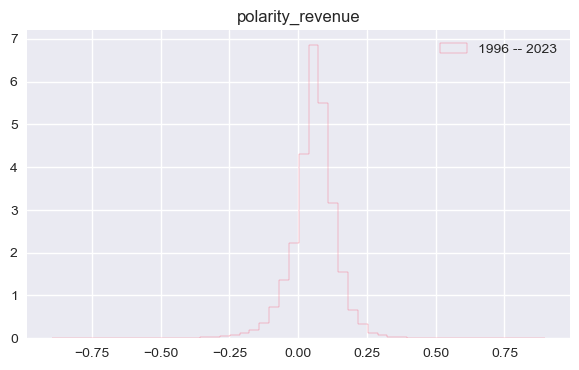

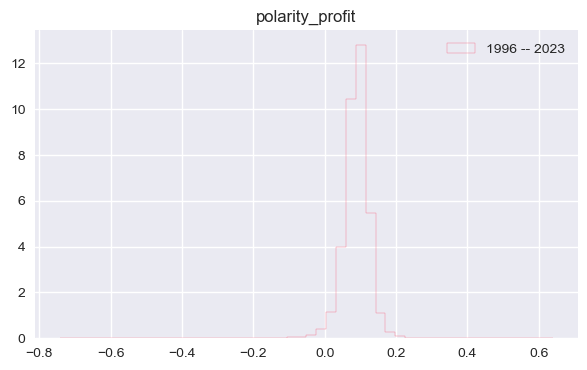

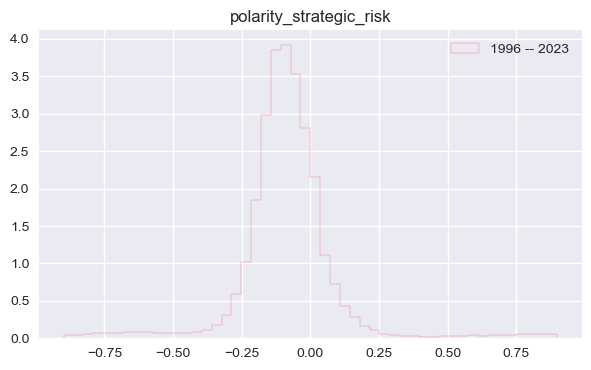

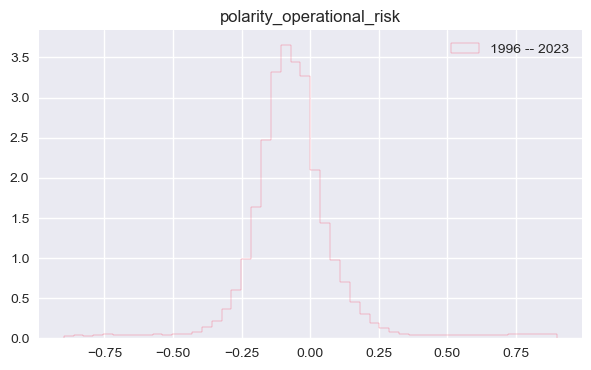

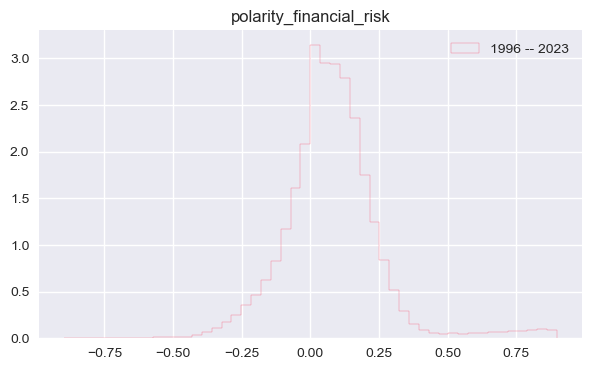

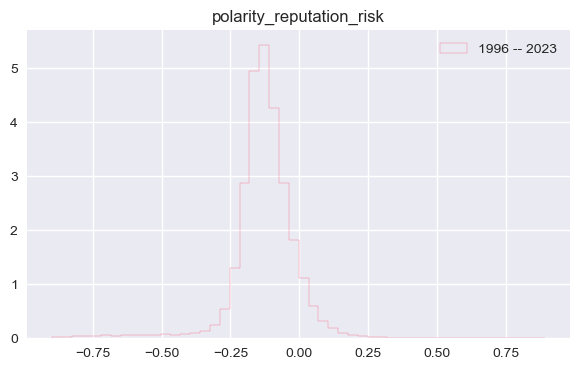

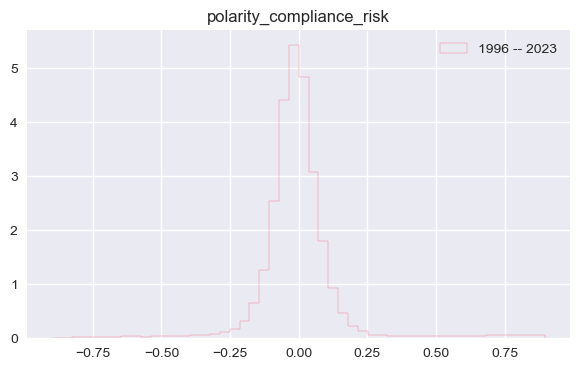

In [789]:
llama = [col for col in sent.columns if 'polarity' in col]

for col in llama: 
    plt.figure(figsize=(7, 4))
    plt.title(col)
    # plt.hist(sent_96[col], bins=50, label='1996 -- 2012', density=True, histtype='step')
    # plt.hist(sent[col], bins=50, label='2013 -- 2023', density=True, histtype='step')
    plt.hist(all_sent[col], bins=50, label='1996 -- 2023', density=True, histtype='step')
    plt.legend()
    plt.show()

In [240]:
all_sent.tail(10)

,CIK,FILING_DATE,ACC_NUM,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk
89370,1941365,20230310,0001941365-23-000022,0.194355,0.143917,0.050438,0.154358,0.186539,-0.032181,0.189102,0.110229,0.078873,0.154686,0.277908,-0.123222,0.119484,0.290649,-0.171165,0.183586,0.196320,-0.012733,0.127686,0.265152,-0.137466,0.186195,0.244820,-0.058624
89371,1941536,20230320,0001193125-23-074792,0.094481,0.210312,-0.115831,0.320404,0.156616,0.163788,0.245651,0.135483,0.110168,0.127522,0.296040,-0.168518,0.105537,0.313301,-0.207764,0.184662,0.224323,-0.039661,0.081135,0.306210,-0.225075,0.153183,0.307213,-0.154030
89372,1944558,20230216,0001944558-23-000024,0.392437,0.048452,0.343985,0.296143,0.117935,0.178207,0.212265,0.129456,0.082809,0.216125,0.195110,0.021015,0.208870,0.167580,0.041290,0.174862,0.149094,0.025768,0.181324,0.180508,0.000816,0.250320,0.166634,0.083687
89373,1945619,20230330,0001683168-23-001957,0.005589,0.313488,-0.307899,0.065857,0.126221,-0.060364,0.162216,0.096207,0.066010,0.091743,0.370651,-0.278908,0.090530,0.365242,-0.274712,0.095352,0.344284,-0.248932,0.139900,0.251308,-0.111408,0.201019,0.229126,-0.028107
89374,1946021,20230213,0001929980-23-000010,0.121727,0.223362,-0.101635,0.110085,0.113853,-0.003769,0.188385,0.097206,0.091179,0.171494,0.252975,-0.081482,0.180489,0.206291,-0.025803,0.217438,0.136650,0.080788,0.142139,0.237289,-0.095150,0.234779,0.195145,0.039635
89375,1948455,20230919,0001213900-23-077437,0.093828,0.251150,-0.157322,0.215485,0.081482,0.134003,0.238468,0.098946,0.139523,0.191422,0.234772,-0.043350,0.187447,0.217674,-0.030228,0.267273,0.106071,0.161201,0.141853,0.247536,-0.105682,0.250092,0.174759,0.075333
89376,1951276,20230928,0000950170-23-050475,0.302252,0.061148,0.241104,0.204483,0.205444,-0.000961,0.143036,0.117920,0.025116,0.268799,0.195885,0.072914,0.290550,0.115242,0.175308,0.223862,0.053146,0.170715,0.184246,0.182049,0.002197,0.219688,0.150436,0.069252
89377,1967306,20231229,0001558370-23-020031,0.335243,0.054060,0.281183,0.246277,0.160919,0.085358,0.187378,0.089752,0.097626,0.227222,0.203651,0.023571,0.246239,0.138077,0.108162,0.246307,0.075447,0.170860,0.138008,0.212601,-0.074593,0.248207,0.153183,0.095024
89378,1967649,20231221,0001967649-23-000025,0.315893,0.074120,0.241774,0.192932,0.046753,0.146179,0.187988,0.106331,0.081657,0.170586,0.264442,-0.093857,0.109367,0.289715,-0.180347,0.194183,0.197166,-0.002983,0.119400,0.272125,-0.152725,0.218292,0.220474,-0.002182
89379,1978811,20231226,0001558370-23-020009,0.255337,0.097689,0.157648,0.228973,0.165161,0.063812,0.178192,0.095840,0.082352,0.270733,0.150978,0.119755,0.265617,0.118141,0.147476,0.275391,0.050644,0.224747,0.219872,0.154018,0.065853,0.280800,0.116913,0.163887


In [146]:
# sent_df = reports_m.merge(sent, on='index', how='inner')
# sent_df.tail()

In [59]:
all_sent['CIK'] = all_sent['CIK'].astype(str)
all_sent['FILING_DATE'] = all_sent['FILING_DATE'].astype(str)
all_sent['ACC_NUM'] = all_sent['ACC_NUM'].astype(str)

In [61]:
# sent_df['tmp'] = np.log(sent_df['mve'])
# sent_df[sent_df['ln_mve'] != sent_df['tmp']][['ln_mve', 'tmp']]
# sent_df.drop('tmp', axis=1, inplace=True)

In [63]:
all_sent.shape

(89380, 27)

In [208]:
all_sent.to_csv('all_sentiment.csv')

In [65]:
df['CIK'] = df['CIK'].astype(str)
df['FILING_DATE'] = df['FILING_DATE'].astype(str)
df['ACC_NUM'] = df['ACC_NUM'].astype(str)

In [67]:
sent_df = df.merge(all_sent, on=['CIK', 'FILING_DATE', 'ACC_NUM'])
sent_df.shape

(55899, 57)

In [71]:
sent_df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55894,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754

In [73]:
sent_df.to_csv('parsed_sent_df.csv')

In [69]:
sent_df['FILING_DATE'].str[:4].value_counts(normalize=True).sort_index()

FILING_DATE
1996    0.017442
1997    0.026816
1998    0.030752
1999    0.033936
2000    0.034044
2001    0.032111
2002    0.036566
2003    0.048337
2004    0.040967
2005    0.047568
2006    0.051754
2007    0.055958
2008    0.056906
2009    0.055600
2010    0.055046
2011    0.052130
2012    0.051468
2013    0.031843
2014    0.034437
2015    0.037031
2016    0.039321
2017    0.040877
2018    0.043650
2019    0.045439
Name: proportion, dtype: float64

In [262]:
llama = [col for col in sent_df.columns if 'polarity' in col]

df_ = sent_df[list(df.columns) + llama].copy()
df_

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,-0.136895,-0.051071,0.095757,-0.215408,-0.246918,-0.155720,-0.214748,-0.121807
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.145316,0.029877,0.079727,-0.060169,0.053898,0.143921,-0.107578,-0.019112
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.065392,0.103439,0.109772,-0.177845,-0.212105,-0.169449,-0.204399,-0.120747
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.201285,0.093811,0.105125,-0.144043,-0.167652,-0.029873,-0.159672,-0.089550
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.188529,0.119324,0.081741,-0.065544,-0.094933,-0.012558,-0.077286,0.018616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55894,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614,-0.104546,0.012009,0.114021,-0.070724,-0.038177,-0.076954,-0.104309,-0.003506
55895,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628,0.125046,-0.021088,0.119873,-0.057945,-0.009373,0.003876,-0.103111,0.019791
55896,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530,0.046911,0.001831,0.111496,-0.079849,-0.012260,0.012787,-0.120361,0.002930
55897,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,3343

In [264]:
target = 'car01'
control_variables = ['mve', 'ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']
lm_tone = ['tone', 'tone_pos', 'tone_neg']
harv_tone = ['tone_harvard', 'tone_posharvard', 'tone_negharvard']
frankel_variables = ['rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'factorpred_car01']
llama = [col for col in sent_df.columns if 'polarity' in col]
len(llama)

8

In [394]:
df = pd.read_sas('replication_package_MS-ACC-20-00126/data/finaldata_10k.sas7bdat')

In [434]:
some_cols = list(set(df.columns) - set(control_variables) - set(lm_tone) - set(harv_tone) - set(frankel_variables) - set([target]) - set(['year', 'datadate', 'filename', 'date_filed', 'mve', 'gvkey']))
some_cols

['volume', 'ceq', 'prcc_f', 'permco', 'csho', 'permno', 'SHROUT']

In [436]:
df[some_cols]

,volume,ceq,prcc_f,permco,csho,permno,SHROUT
0,8818300.0,204.635,22.124999,20000.0,15.998,54594.0,16025.0
1,21456200.0,269.259,30.999985,20000.0,18.204,54594.0,18156.0
2,18200800.0,300.850,26.437500,20000.0,27.704,54594.0,27690.0
3,25769400.0,326.035,19.750000,20000.0,27.381,54594.0,27443.0
4,25843200.0,339.515,13.875000,20000.0,26.865,54594.0,26963.0
...,...,...,...,...,...,...,...
75357,59346255.0,976.002,10.530000,54852.0,54.975,14642.0,54967.0
75358,58762972.0,959.413,7.490000,54852.0,55.090,14642.0,55107.0
75359,40707109.0,912.683,6.420000,54852.0,55.168,14642.0,55167.0
75360,334320819.0,9208.000,51.710000,55804.0,199.853,16496.0,142348.0


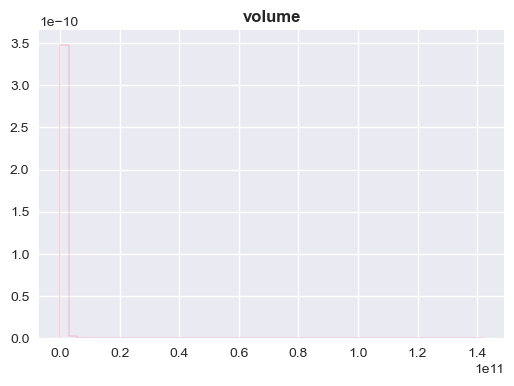

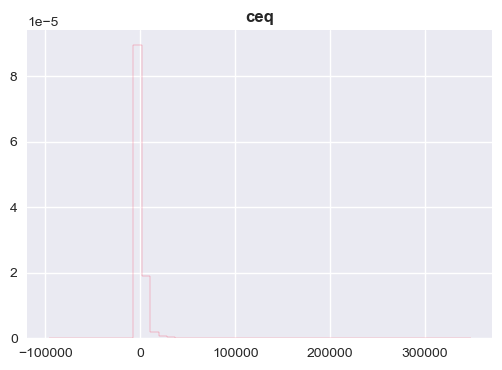

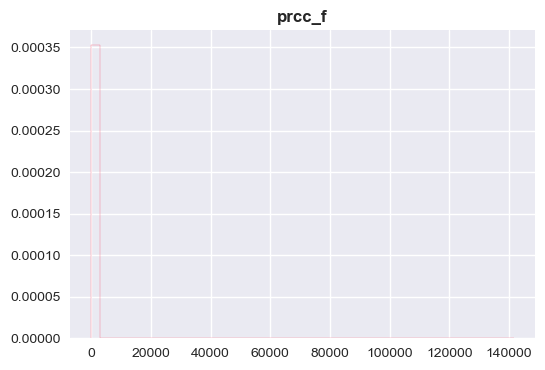

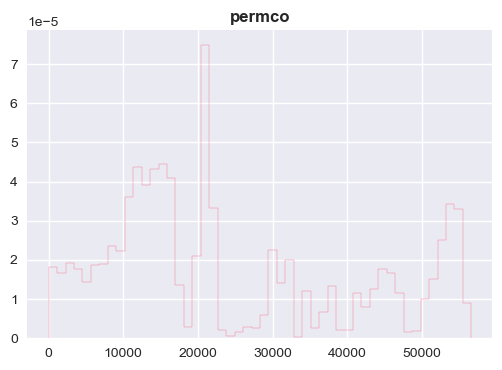

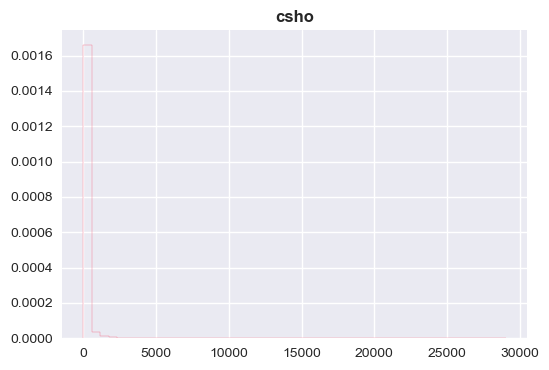

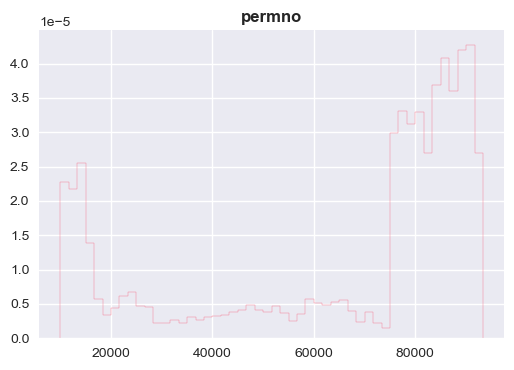

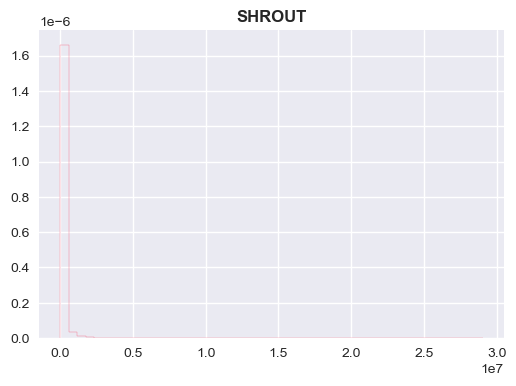

In [438]:
for f in some_cols:
    plt.figure(figsize=(6, 4))
    plt.title(f, weight='bold')
    df[f].hist(bins=50, histtype='step', density=True)
    plt.show()

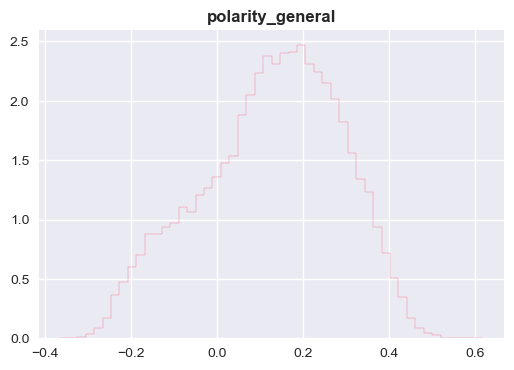

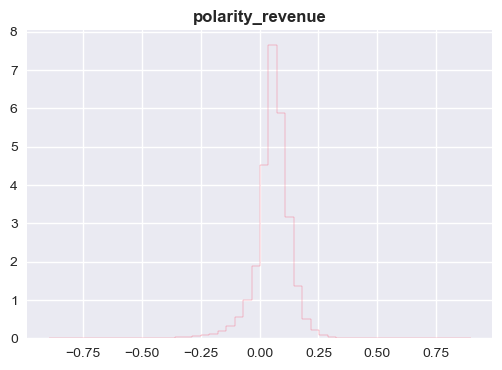

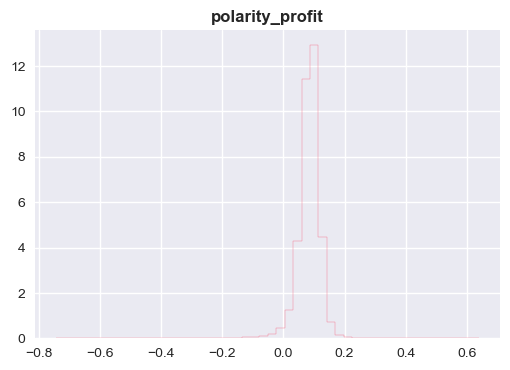

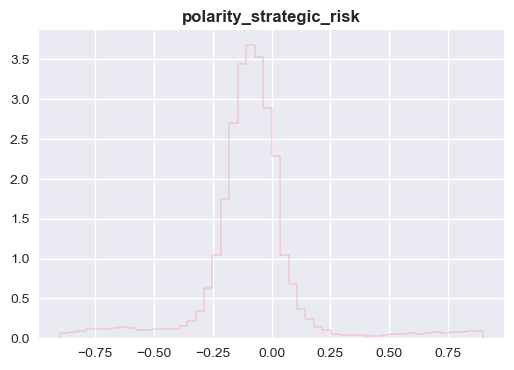

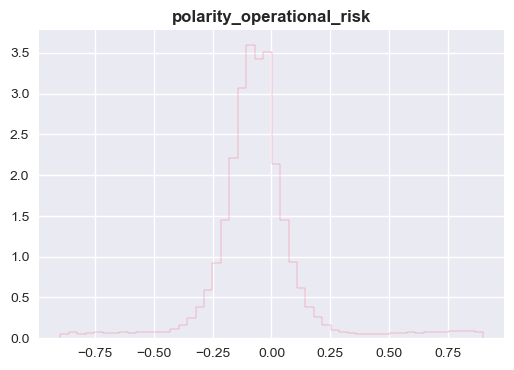

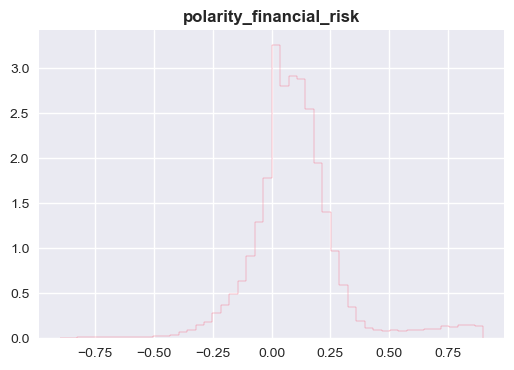

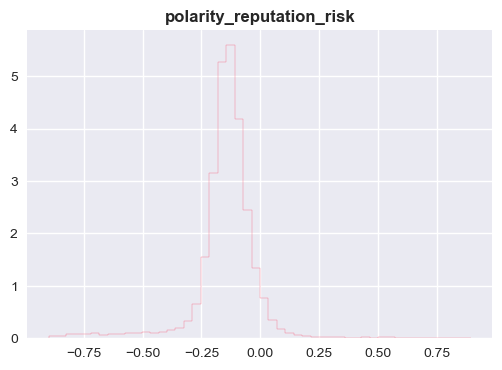

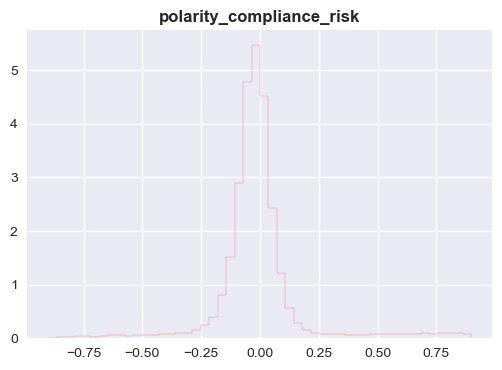

In [266]:
for f in llama:
    plt.figure(figsize=(6, 4))
    plt.title(f, weight='bold')
    df_[f].hist(bins=50, histtype='step', density=True)
    plt.show()

In [268]:
# for column in llama:
#     df_[column] = winsorize(df_[column], limits=[0.01, 0.01])
df_.shape

## Table 1 panel A

Mean differs a little from the full period but not significantly

In [272]:
table1 = round(df_[[target] + lm_tone + harv_tone + frankel_variables + control_variables + llama].describe(), 3)
table1.loc[['mean', 'std', '25%', '50%', '75%']].T

,mean,std,25%,50%,75%
car01,-0.001,0.049,-0.020,-0.001,0.018
tone,-0.284,0.170,-0.402,-0.304,-0.190
tone_pos,0.006,0.001,0.005,0.006,0.007
tone_neg,0.012,0.004,0.009,0.012,0.014
tone_harvard,0.268,0.106,0.197,0.277,0.346
tone_posharvard,0.059,0.008,0.054,0.059,0.064
tone_negharvard,0.035,0.009,0.028,0.033,0.040
rfpred_car01,-0.001,0.014,-0.006,-0.000,0.005
svrpred_car01,-0.000,0.057,-0.030,0.001,0.031
sldapred_car01,-0.001,0.006,-0.004,-0.001,0.002


## Table 2 panel A

In [274]:
def create_mixed_correlation_matrix_efficient(df):
    
    pearson_corr = df.corr(method='pearson').values
    spearman_corr = df.corr(method='spearman').values
    
    upper_mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
    lower_mask = np.tril(np.ones_like(spearman_corr, dtype=bool), k=-1)
    
    mixed_matrix = pearson_corr.copy()
    mixed_matrix[lower_mask] = spearman_corr[lower_mask]
    np.fill_diagonal(mixed_matrix, 1.0)

    cor = pd.DataFrame(mixed_matrix,
                       index=df.columns, 
                       columns=df.columns)
    
    return round(cor, 2)

In [276]:
table2 = create_mixed_correlation_matrix_efficient(df_[lm_tone + harv_tone + frankel_variables + llama])
table2

,tone,tone_pos,tone_neg,tone_harvard,tone_posharvard,tone_negharvard,rfpred_car01,svrpred_car01,sldapred_car01,factorpred_car01,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
tone,1.00,0.42,-0.80,0.39,-0.18,-0.42,0.03,0.02,0.08,0.03,0.15,0.10,0.09,0.07,0.14,0.31,-0.04,0.14
tone_pos,0.43,1.00,0.14,-0.02,0.24,0.14,-0.03,-0.01,-0.01,-0.03,-0.02,0.00,0.02,-0.07,-0.07,-0.01,-0.02,-0.04
tone_neg,-0.78,0.16,1.00,-0.45,0.33,0.55,-0.05,-0.03,-0.08,-0.05,-0.18,-0.11,-0.09,-0.11,-0.18,-0.33,0.01,-0.17
tone_harvard,0.39,-0.03,-0.45,1.00,0.10,-0.86,-0.03,-0.01,-0.02,-0.02,-0.04,0.03,0.05,0.03,0.11,0.12,-0.04,0.09
tone_posharvard,-0.16,0.25,0.34,0.09,1.00,0.40,0.02,-0.01,0.03,0.02,0.10,0.03,0.00,0.07,0.05,-0.17,0.09,-0.03
tone_negharvard,-0.44,0.17,0.60,-0.85,0.41,1.00,0.04,0.00,0.04,0.03,0.09,-0.01,-0.04,0.01,-0.07,-0.18,0.08,-0.09
rfpred_car01,0.03,-0.04,-0.07,-0.02,0.03,0.03,1.00,0.58,0.34,0.85,0.16,0.08,0.04,0.08,0.07,0.07,0.02,0.05
svrpred_car01,0.01,-0.01,-0.03,-0.00,-0.01,-0.00,0.52,1.00,0.14,0.78,0.07,0.03,0.01,0.03,0.03,0.04,0.00,0.02
sldapred_car01,0.07,-0.00,-0.08,-0.00,0.04,0.01,0.34,0.13,1.00,0.51,0.18,0.09,0.04,0.09,0.11,0.13,-0.01,0.06
factorpred_car01,0.02,-0.03,-0.05,-0.02,0.03,0.03,0.81,0.77,0.51,1.00,0.15,0.06,0.03,0.08,0.07,0.07,0.02,0.04


In [282]:
table2_with_target = create_mixed_correlation_matrix_efficient(df_[[target] + lm_tone + harv_tone + frankel_variables + llama])
table2_with_target[['car01']]

,car01
car01,1.00
tone,0.00
tone_pos,-0.00
tone_neg,-0.01
tone_harvard,-0.02
tone_posharvard,0.01
tone_negharvard,0.02
rfpred_car01,0.03
svrpred_car01,0.00
sldapred_car01,0.03


In [198]:
# table2_with_target.loc['car01']

## Table 3 Panel A
We estimate Equation (1) separately for each of the following measures of SENTIMENTi,t

In [995]:
def panel_ols_fe(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    # X = add_constant(subset[x_vars])
    # y = subset[target]
    # clusters = subset[cluster_var]

    formula = f"{target} ~ C(gvkey) + C(year) + " + " + ".join(x_vars)
    
    model = smf.ols(formula=formula, data=subset)
    results = model.fit()
    
    # model = OLS(y, X).fit()
    # results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [1033]:
df_panel.tail()

datadate  prcc_f     csho       ceq   instown   permco  \
gvkey     year                                                              
b'317264' 2017.0 2017-03-31   10.53   54.975   976.002  0.000000  54852.0   
          2018.0 2018-03-31    7.49   55.090   959.413  0.565377  54852.0   
          2019.0 2019-03-31    6.42   55.168   912.683  0.529435  54852.0   
b'318728' 2018.0 2017-12-31   51.71  199.853  9208.000  0.000000  55804.0   
          2019.0 2018-12-31   39.83  197.100  8276.000  0.722051  55804.0   

                   permno  date_filed                         filename  \
gvkey     year                                                           
b'317264' 2017.0  14642.0  2017-06-14  b'1596993_0001596993-17-000010'   
          2018.0  14642.0  2018-06-28  b'1596993_0001596993-18-000015'   
          2019.0  14642.0  2019-05-30  b'1596993_0001596993-19-000010'   
b'318728' 2018.0  16496.0  2018-02-26  b'1527469_0001527469-18-000011'   
          2019.0  16496.0  2019-02-27  b'1527469_0001527469-19-000007'   

                          mve       btm       volume    SHROUT  turnover  \
gvkey     year                                                             
b'317264' 2017.0    578.88675  1.685998   59346255.0   54967.0  1.079671   
          2018.0    412.62410  2.325150   58762972.0   55107.0  1.066343   
          2019.0    354.17856  2.508930   40707109.0   55167.0  0.737889   
b'318728' 2018.0  10334.39863  0.891005  334320819.0  142348.0  2.348616   
          2019.0   7850.49300  1.054201  338861633.0  164849.0  2.055588   

                  pre_alpha  nasdaq     car01  tone_pos  tone_neg      tone  \
gvkey     year                                                                
b'317264' 2017.0  -0.000467     0.0 -0.029018  0.005495  0.014015 -0.436735   
          2018.0  -0.000395     0.0 -0.047430  0.005525  0.014667 -0.452713   
          2019.0   0.000974     0.0 -0.027795  0.005649  0.013585 -0.412628   
b'318728' 2018.0  -0.000431     0.0 -0.001046  0.007346  0.013908 -0.308759   
          2019.0  -0.000151     0.0  0.006164  0.007526  0.013676 -0.290089   

                  tone_posharvard  tone_negharvard  tone_harvard  \
gvkey     year                                                     
b'317264' 2017.0         0.053671         0.033333      0.233754   
          2018.0         0.052688         0.033028      0.229364   
          2019.0         0.054438         0.032027      0.259187   
b'318728' 2018.0         0.077755         0.048643      0.230316   
          2019.0         0.077833         0.049895      0.224715   

                  rfpred_car01  svrpred_car01  sldapred_car01    ln_mve  \
gvkey     year                                                            
b'317264' 2017.0     -0.007481       0.061267       -0.005647  6.361107   
          2018.0     -0.012188       0.007985        0.001820  6.022537   
          2019.0     -0.016984      -0.063728        0.008236  5.869801   
b'318728' 2018.0      0.001199       0.015440        0.010414  9.243233   
          2019.0      0.001628      -0.119722       -0.002462  8.968332   

                  factorpred_car01               ACC_NUM      CIK FILING_DATE  \
gvkey     year                                                                  
b'317264' 2017.0         -0.123893  0001596993-17-000010  1596993    20170614   
          2018.0         -0.338591  0001596993-18-000015  1596993    20180628   
          2019.0         -0.797175  0001596993-19-000010  1596993    20190530   
b'318728' 2018.0          0.560623  0001527469-18-000011  1527469    20180226   
          2019.0         -1.054262  0001527469-19-000007  1527469    20190227   

                  polarity_general  polarity_revenue  polarity_profit  \
gvkey     year                                                          
b'317264' 2017.0         -0.104546          0.012009         0.114021   
          2018.0          0.125046         -0.021088         0.119873   
          

In [1035]:
df_panel.columns

Index(['datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco', 'permno',
       'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT', 'turnover',
       'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg', 'tone',
       'tone_posharvard', 'tone_negharvard', 'tone_harvard', 'rfpred_car01',
       'svrpred_car01', 'sldapred_car01', 'ln_mve', 'factorpred_car01',
       'ACC_NUM', 'CIK', 'FILING_DATE', 'polarity_general', 'polarity_revenue',
       'polarity_profit', 'polarity_strategic_risk',
       'polarity_operational_risk', 'polarity_financial_risk',
       'polarity_reputation_risk', 'polarity_compliance_risk',
       'rfpred_car01_quintile', 'tone_quintile', 'tone_harvard_quintile',
       'polarity_general_quintile', 'polarity_financial_risk_quintile',
       'polarity_revenue_quintile'],
      dtype='object')

In [1037]:
# panel_ols_fe(df_, target, ['tone'] + control_variables, 'gvkey')
target = 'car01'
x_vars = ['rfpred_car01'] + control_variables

formula = f"{target} ~ EntityEffects + TimeEffects + " + " + ".join(x_vars)

model = PanelOLS.from_formula(formula, df_panel)
res = model.fit()

In [1039]:
print(res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  car01   R-squared:                        0.0230
Estimator:                   PanelOLS   R-squared (Between):             -0.2292
No. Observations:               55899   R-squared (Within):               0.0225
Date:                Sat, Oct 25 2025   R-squared (Overall):             -0.1552
Time:                        16:47:25   Log-likelihood                 9.625e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      159.48
Entities:                        8448   P-value                           0.0000
Avg Obs:                       6.6168   Distribution:                 F(7,47421)
Min Obs:                       1.0000                                           
Max Obs:                       24.000   F-statistic (robust):             159.48
                            

In [1005]:
df_panel = df_.set_index(['gvkey', 'year'])

In [284]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [286]:
control_variables = ['ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']

In [288]:
results = ols_with_cluster(df_, 'car01', ['tone'] + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     23.45
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.13e-32
Time:                        09:26:34   Log-Likelihood:                 89203.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55891   BIC:                        -1.783e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.001     -1.008      0.3

## Table 3 Panel B

In [290]:
def fit_one_factor(df, sentiment_features, control_variables):
    features_res = {}
    
    for f in sentiment_features:
        results = ols_with_cluster(df, 'car01', [f] + control_variables, 'gvkey')
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[1], 3)
        features_res[f]['t'] = round(results.tvalues[1], 3)
        features_res[f]['r2_adj'] = round(100*results.rsquared_adj, 3)
        pval = round(results.pvalues[1], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    return features_res

In [292]:
sentiment_features = lm_tone + harv_tone + frankel_variables + llama

In [119]:
# full period sample (75k)

# table3_res = fit_one_factor(df, sentiment_features, control_variables)

# table3 = pd.DataFrame(table3_res).T.drop('model', axis=1)
# table3['coef'] = table3['coef'].astype(str) + table3['sgnf']
# table3[['coef', 't', 'r2_adj']]

,coef,t,r2_adj
tone,0.001,1.123,0.459
tone_pos,-0.16,-1.08,0.459
tone_neg,-0.05,-0.979,0.458
tone_harvard,-0.005***,-3.035,0.468
tone_posharvard,-0.01,-0.442,0.457
tone_negharvard,0.051***,2.607,0.465
rfpred_car01,0.069***,3.944,0.495
svrpred_car01,0.006,1.446,0.462
sldapred_car01,0.147***,4.324,0.487
factorpred_car01,0.001***,3.52,0.484


In [354]:
df_96_08 = df_[df_['FILING_DATE'].str[:4] <= '2008'].copy().reset_index(drop=True)
# df_96_08['FILING_DATE'].str[:4].value_counts().sort_index()

In [356]:
df_08_19 = df_[df_['FILING_DATE'].str[:4] > '2008'].copy().reset_index(drop=True)
# df_08_19['FILING_DATE'].str[:4].value_counts().sort_index()

In [366]:
table3_lm = fit_one_factor(df[df['FILING_DATE'].str[:4] <= '2008'], lm_tone, control_variables)

table3_period_lm = pd.DataFrame(table3_lm).T.drop('model', axis=1)
table3_period_lm['coef'] = table3_period_lm['coef'].astype(str) + table3_period_lm['sgnf']
# table3_period_lm[['coef', 't', 'r2_adj', 'pval']]

In [380]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [979]:
tone_res2 = {}

for tone in ['tone', 'rfpred_car01', 'polarity_general', 'polarity_revenue', 'polarity_financial_risk']:
    tone_year = []
    r2_year = []
    
    for year in range(1996, 2020):
        df_period = df_[df_['FILING_DATE'].str[:4] == str(year)].copy().reset_index(drop=True)
        res_period = fit_one_factor(df_period, [tone], control_variables)
        
        tone_year.append(res_period[tone]['t'])
        r2_year.append(res_period[tone]['r2_adj'])
        
    tone_res2[tone] = {}
    tone_res2[tone]['t'] = np.abs(np.array(tone_year))
    tone_res2[tone]['r2_adj'] = np.array(r2_year)

In [961]:
res_period['polarity_financial_risk']['r2_adj']

0.078

In [955]:
res_period = fit_one_factor(df_period, [tone], control_variables)

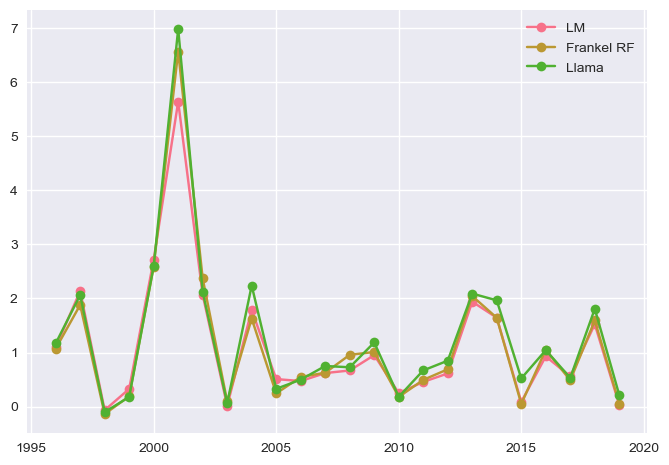

In [985]:
plt.figure()
plt.plot(range(1996, 2020), tone_res2['tone']['r2_adj'], marker='o', label='LM')
plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['r2_adj'], marker='o', label='Frankel RF')
plt.plot(range(1996, 2020), tone_res2['polarity_general']['r2_adj'], marker='o', label='Llama')        
# plt.plot(range(1996, 2020), tone_res['polarity_financial_risk'], marker='o', label='Llama financial risk')
plt.legend()
plt.show()
# tone_res2['tone']['r2_adj']

In [981]:
tone_res2

{'tone': {'t': array([0.553, 2.449, 1.256, 1.662, 1.708, 1.258, 1.61 , 0.405, 2.209,
         2.884, 1.045, 0.592, 2.695, 1.39 , 1.405, 0.723, 0.023, 1.485,
         0.421, 1.529, 0.239, 1.366, 0.016, 0.017]),
  'r2_adj': array([ 1.095,  2.135, -0.066,  0.327,  2.715,  5.637,  2.065,  0.014,
          1.787,  0.509,  0.472,  0.62 ,  0.668,  0.952,  0.25 ,  0.457,
          0.613,  1.939,  1.643,  0.087,  0.929,  0.558,  1.523,  0.031])},
 'rfpred_car01': {'t': array([0.005, 1.292, 0.297, 0.445, 0.373, 4.112, 2.63 , 1.248, 0.662,
         0.129, 1.342, 0.461, 2.952, 1.629, 0.058, 0.953, 0.998, 1.305,
         0.288, 0.712, 1.199, 0.041, 0.869, 0.579]),
  'r2_adj': array([ 1.069,  1.88 , -0.137,  0.191,  2.587,  6.562,  2.369,  0.097,
          1.627,  0.243,  0.548,  0.626,  0.957,  1.01 ,  0.179,  0.494,
          0.69 ,  2.043,  1.642,  0.05 ,  1.051,  0.486,  1.592,  0.057])},
 'polarity_general': {'t': array([0.893, 2.039, 0.87 , 0.101, 0.539, 5.1  , 1.727, 1.147, 3.599,
         1.

In [382]:
table3_period_other = fit_one_factor(df_96_08, harv_tone + frankel_variables + llama, control_variables)

table3_period_other = pd.DataFrame(table3_period_other).T.drop('model', axis=1)
table3_period_other['coef'] = table3_period_other['coef'].astype(str) + table3_period_other['sgnf']

table3_period = pd.concat([table3_period_lm[['coef', 't', 'r2_adj', 'pval']],
                           table3_period_other[['coef', 't', 'r2_adj', 'pval']]
                          ], axis=0)
print(color.BOLD + 'Early sample period (1996-2008)' + color.END)
table3_period

Early sample period (1996-2008)


,coef,t,r2_adj,pval
tone,0.003***,2.61,0.79,0.009
tone_pos,-0.371**,-2.112,0.785,0.035
tone_neg,-0.237***,-3.443,0.803,0.001
tone_harvard,-0.0,-0.032,0.694,0.974
tone_posharvard,-0.03,-0.838,0.696,0.402
tone_negharvard,-0.018,-0.424,0.695,0.672
rfpred_car01,0.104***,3.579,0.766,0.0
svrpred_car01,0.007,1.18,0.701,0.238
sldapred_car01,0.126**,2.244,0.717,0.025
factorpred_car01,0.001***,2.58,0.727,0.01


In [384]:
table3_period_res = fit_one_factor(df_08_19, sentiment_features, control_variables)

table3_period = pd.DataFrame(table3_period_res).T.drop('model', axis=1)
table3_period['coef'] = table3_period['coef'].astype(str) + table3_period['sgnf']
print(color.BOLD + 'Extra sample period (2009-2019)' + color.END)
table3_period[['coef', 't', 'r2_adj', 'pval']]

Extra sample period (2009-2019)


,coef,t,r2_adj,pval
tone,-0.004,-1.538,0.337,0.124
tone_pos,0.008,0.027,0.329,0.978
tone_neg,0.166,1.635,0.338,0.102
tone_harvard,-0.007***,-2.586,0.351,0.01
tone_posharvard,-0.035,-0.782,0.331,0.434
tone_negharvard,0.069**,2.112,0.342,0.035
rfpred_car01,0.028,1.025,0.336,0.305
svrpred_car01,0.001,0.212,0.329,0.832
sldapred_car01,0.079,1.369,0.337,0.171
factorpred_car01,0.0,1.026,0.336,0.305


In [386]:
table3_period_res = fit_one_factor(df_, sentiment_features, control_variables)

table3_period = pd.DataFrame(table3_period_res).T.drop('model', axis=1)
table3_period['coef'] = table3_period['coef'].astype(str) + table3_period['sgnf']
print(color.BOLD + 'Full sample period (1996-2019)' + color.END)
table3_period[['coef', 't', 'r2_adj', 'pval']]

Full sample period (1996-2019)


,coef,t,r2_adj,pval
tone,0.001,0.584,0.421,0.559
tone_pos,-0.136,-0.778,0.421,0.437
tone_neg,-0.012,-0.194,0.42,0.847
tone_harvard,-0.005***,-2.802,0.433,0.005
tone_posharvard,-0.011,-0.406,0.42,0.685
tone_negharvard,0.056**,2.51,0.43,0.012
rfpred_car01,0.064***,3.158,0.454,0.002
svrpred_car01,0.004,0.843,0.422,0.399
sldapred_car01,0.134***,3.407,0.445,0.001
factorpred_car01,0.001***,2.822,0.444,0.005


## Multivariate regressions

In [445]:
sentiment_features

['tone',
 'tone_pos',
 'tone_neg',
 'tone_harvard',
 'tone_posharvard',
 'tone_negharvard',
 'rfpred_car01',
 'svrpred_car01',
 'sldapred_car01',
 'factorpred_car01',
 'polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

In [456]:
results = ols_with_cluster(df_, 'car01', lm_tone + frankel_variables + llama + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     13.32
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.12e-46
Time:                        14:26:46   Log-Likelihood:                 89278.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55877   BIC:                        -1.783e+05
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [709]:
# lm_tone + harv_tone + frankel_variables + llama
results = ols_with_cluster(df_, 'car01', lm_tone + control_variables, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     19.52
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.27e-33
Time:                        14:54:47   Log-Likelihood:                 89208.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55889   BIC:                        -1.783e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.002      1.435      

In [653]:
# print('LM RMSE', round(np.sqrt(results.mse_resid), 5))

X = add_constant(df_[lm_tone + control_variables])
y_pred = results.predict(X)

lm_dict = {}
lm_dict['rmse'] = np.sqrt(results.mse_resid)
lm_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict['r2_adj'] = results.rsquared_adj
lm_dict
                         
# print('LM RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('LM MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('LM R2', round(results.rsquared_adj, 4))

{'rmse': 0.04905884158643665,
 'mae': 0.17900772052741823,
 'r2_adj': 0.004348924996459669}

In [711]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables + control_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     18.36
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.05e-33
Time:                        14:54:59   Log-Likelihood:                 89217.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55888   BIC:                        -1.783e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0011     

In [657]:
print('Frankel RMSE', round(np.sqrt(results_fr.mse_resid), 5))

X = add_constant(df_[frankel_variables + control_variables])
y_pred = results_fr.predict(X)
# print('Frankel RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Frankel MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Frankel R2', round(results_fr.rsquared_adj, 4))

fr_dict = {}
fr_dict['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict['r2_adj'] = results_fr.rsquared_adj
fr_dict

Frankel RMSE 0.04905


{'rmse': 0.04905156593933803,
 'mae': 0.1789713154635392,
 'r2_adj': 0.004644222172728307}

In [746]:
llama = ['polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

# llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

In [748]:
results_llama = ols_with_cluster(df_, 'car01', llama + control_variables, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     18.07
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.77e-45
Time:                        16:23:16   Log-Likelihood:                 89265.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55884   BIC:                        -1.784e+05
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const           

In [750]:
# print('Llama RMSE', round(np.sqrt(results_llama.mse_resid), 6))

X = add_constant(df_[llama + control_variables])
y_pred = results_llama.predict(X)
# print('Llama RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Llama MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Llama R2', round(results_llama.rsquared_adj, 4))

llama_dict = {}
llama_dict['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict['r2_adj'] = results_llama.rsquared_adj
llama_dict

{'rmse': 0.04900522712386684,
 'mae': 0.1789388649652172,
 'r2_adj': 0.006257288975319519}

In [752]:
lm_df = pd.DataFrame.from_dict(lm_dict, orient='index')
lm_df.columns = ['LM']

fr_df = pd.DataFrame.from_dict(fr_dict, orient='index')
fr_df.columns = ['Frankel']

llama_df = pd.DataFrame.from_dict(llama_dict, orient='index')
llama_df.columns = ['Llama']

res_df = pd.concat([lm_df, fr_df, llama_df], axis=1)
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


### Without control

In [770]:
results = ols_with_cluster(df_, 'car01', lm_tone, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.719
Date:                Tue, 21 Oct 2025   Prob (F-statistic):            0.00271
Time:                        16:25:09   Log-Likelihood:                 89088.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55895   BIC:                        -1.781e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.002      2.400      

In [772]:
X = add_constant(df_[lm_tone])
y_pred = results.predict(X)

lm_dict2 = {}
lm_dict2['rmse'] = np.sqrt(results.mse_resid)
lm_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict2['r2_adj'] = results.rsquared_adj
# lm_dict2

In [774]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.37
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.37e-09
Time:                        16:25:16   Log-Likelihood:                 89116.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55894   BIC:                        -1.782e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0007     

In [776]:
X = add_constant(df_[frankel_variables])
y_pred = results_fr.predict(X)
fr_dict2 = {}
fr_dict2['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict2['r2_adj'] = results_fr.rsquared_adj
fr_dict2

{'rmse': 0.049138229412405136,
 'mae': 0.17906464890022694,
 'r2_adj': 0.0011239598033245812}

In [778]:
llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

results_llama = ols_with_cluster(df_, 'car01', llama, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     53.16
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           4.92e-34
Time:                        16:25:21   Log-Likelihood:                 89192.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55895   BIC:                        -1.783e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const               

In [780]:
X = add_constant(df_[llama])
y_pred = results_llama.predict(X)

llama_dict2 = {}
llama_dict2['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict2['r2_adj'] = results_llama.rsquared_adj
llama_dict2

{'rmse': 0.049068739149443694,
 'mae': 0.17898868362969753,
 'r2_adj': 0.003875861344565412}

In [782]:
# without control
lm_df2 = pd.DataFrame.from_dict(lm_dict2, orient='index')
lm_df2.columns = ['LM']

fr_df2 = pd.DataFrame.from_dict(fr_dict2, orient='index')
fr_df2.columns = ['Frankel']

llama_df2 = pd.DataFrame.from_dict(llama_dict2, orient='index')
llama_df2.columns = ['Llama']

res_df2 = pd.concat([lm_df2, fr_df2, llama_df2], axis=1)
round(res_df2, 4)

,LM,Frankel,Llama
rmse,0.0492,0.0491,0.0491
mae,0.1791,0.1791,0.1790
r2_adj,0.0002,0.0011,0.0039


In [768]:
# with control
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


In [ ]:
# fixed effects 
subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)

## Figure 1
Filing Returns and Sentiment

In [308]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    df_[f'{f}_quintile'] = pd.qcut(df_[f], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')

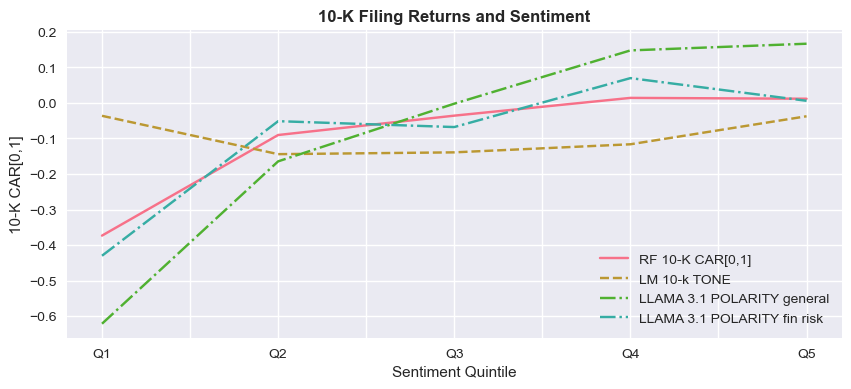

In [310]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
(100*df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.legend();

In [312]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    df_[f'{f}_quintile'] = pd.qcut(df_[f], q=10,  duplicates='drop')

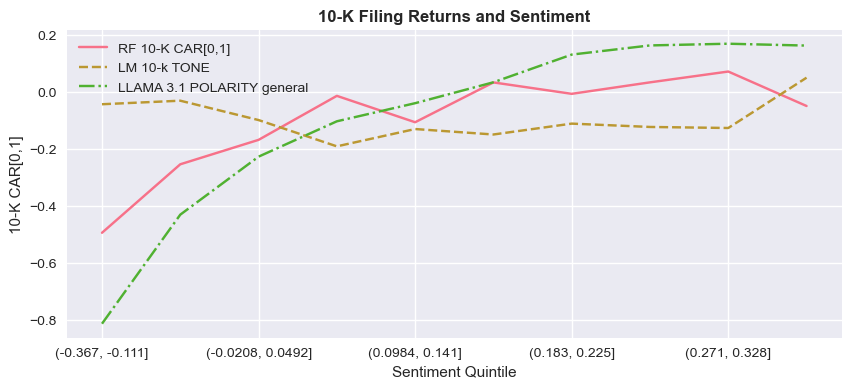

In [316]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
# (100*df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.legend();

In [388]:
df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.178560,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.398630,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226


In [390]:
df.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE'],
      dtype='object')

In [800]:
df_[['polarity_general', 'year']]

,polarity_general,year
0,-0.136895,2002.0
1,0.145316,2003.0
2,0.065392,2004.0
3,0.201285,2005.0
4,0.188529,2006.0
...,...,...
55894,-0.104546,2017.0
55895,0.125046,2018.0
55896,0.046911,2019.0
55897,0.212727,2018.0


In [1041]:
# df_.groupby('year').agg({'polarity_general': 'mean'}

In [1044]:
!pip install factor_analyzer --quiet

In [1049]:
from factor_analyzer import FactorAnalyzer

In [1051]:
df_.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE', 'polarity_general',
       'polarity_revenue', 'polarity_profit', 'polarity_strategic_risk',
       'polarity_operational_risk', 'polarity_financial_risk',
       'polarity_reputation_risk', 'polarity_compliance_risk',
       'rfpred_car01_quintile', 'tone_quintile', 'tone_harvard_quintile',
       'polarity_general_quintile', 'polarity_financial_risk_quintile',
       'polarity_revenue_quintile'],
      dtype='object')

In [1095]:
x = df_[['rfpred_car01', 'svrpred_car01', 'sldapred_car01']]

In [1098]:
fa = FactorAnalyzer(n_factors=1)

In [1100]:
y = fa.fit_transform(x)

In [1102]:
y.shape

(55899, 1)

In [1104]:
df_['y'] = y
df_[['factorpred_car01', 'y']].corr()

,factorpred_car01,y
factorpred_car01,1.000000,-0.841221
y,-0.841221,1.000000


In [ ]:
fa.